In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import glob
import xarray as xr
import xesmf as xe
import matplotlib.pyplot as plt

In [2]:
import warnings
warnings.filterwarnings("ignore")

### Overview

This notebook performs the following steps: 
* saves original GPCC 2.5 deg data as new file with precip renamed to pr
* coarsens the GPCC 2.5 degree data to 5x5 degree (also renaming precip to pr)
* uses the 0.5 deg GPCC data to create a shifted 2.5 degree grid, then regrids to same 5x5 degree grid. This is to test the effects of regridding with a shift (vs a pure coarsening) on the later results
* saves a land mask corresponding to the 2.5 and 5 degree grids

* coarsens MSWEP to 5 degree
* coarses GPCP to 5 degree
  
All regridding uses the "conservative_normed" method. This is the same as conservative, but with a mask applied to handle nans (over the ocean). xESMF masking is explained here: https://pangeo-xesmf.readthedocs.io/en/latest/notebooks/Masking.html

### Read 2.5 degree GPCC monthly precipitation data

In [3]:
ds = xr.open_dataset("../../../../DATA/GPCC_Monthly_Precip/v2020/precip.mon.total.2.5x2.5.v2020.nc").rename({"precip":"pr"})

In [4]:
ds

<xarray.Dataset> Size: 64MB
Dimensions:  (lat: 72, lon: 144, time: 1548)
Coordinates:
  * lat      (lat) float32 288B 88.75 86.25 83.75 81.25 ... -83.75 -86.25 -88.75
  * lon      (lon) float32 576B 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
  * time     (time) datetime64[ns] 12kB 1891-01-01 1891-02-01 ... 2019-12-01
Data variables:
    pr       (time, lat, lon) float32 64MB ...
Attributes:
    history:          Created 09/2018  based on V2018 data obtained via ftp
    title:            GPCC Full Data Reanalysis Version 2018 2.5x2.5 Monthly ...
    Conventions:      CF 1.0
    References:       https://www.psl.noaa.gov/data/gridded/data.gpcc.html
    Original_Source:  http://www.dwd.de/en/FundE/Klima/KLIS/int/GPCC/GPCC.htm...
    Reference:        Users of the data sets are kindly requested to give fee...
    original_source:  ftp://ftp-anon.dwd.de/pub/data/gpcc/html/fulldata_downl...
    dataset_title:    Global Precipitation Climatology Centre (GPCC)

### Regrid to 5x5

In [5]:
# define grid
out_res = 5
orig_grid_with_bounds = xr.Dataset({'lon': ds.lon,
                           'lat': ds.lat,
                           'lon_b': np.linspace(0, 360, 145), 
                           'lat_b': np.linspace(90, -90, 73),
                          })

dest_grid_with_bounds = xr.Dataset({'lon': np.arange(0+out_res/2, 360+out_res/2, out_res),
                         'lat': np.arange(-90+out_res/2, 90+out_res/2, out_res),
                         'lon_b': np.linspace(0, 360, 73),
                         'lat_b': np.linspace(-90, 90, 37), # fix half-polar cells
                          })

In [6]:
## use bilinear regridding to create land mask for 5x5 degree grid
regridder_bi = xe.Regridder(orig_grid_with_bounds, dest_grid_with_bounds, method='bilinear', periodic=True)
ds_regrid_bi = regridder_bi(ds, keep_attrs=True)
mask5 = xr.where(~np.isnan(ds_regrid_bi["pr"].isel(time=0)),1,0).drop_vars("time")

Check land mask:

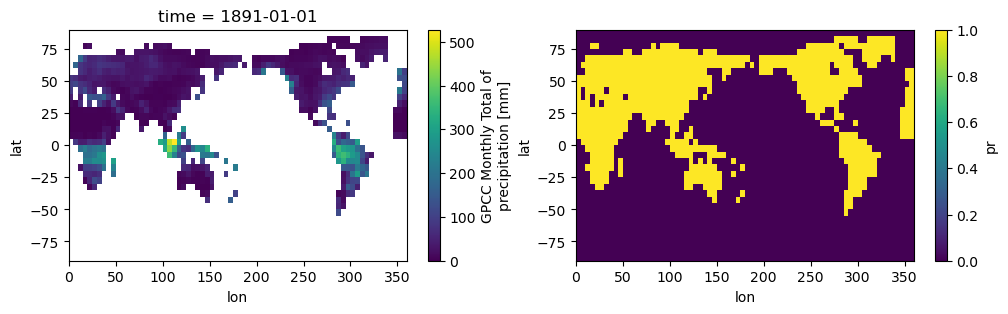

In [7]:
fig, axes = plt.subplots(1, 2, figsize = (12,3))
ds_regrid_bi.isel(time = 0).pr.plot(ax=axes[0])
mask5.plot(ax=axes[1])

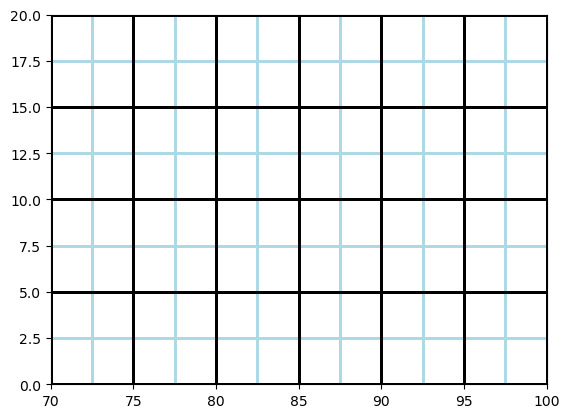

In [8]:
# create a plot of grids to double check
fig, ax = plt.subplots()

ax.pcolormesh(ds.sel(lon = slice(70, 100)).lon, ds.sel(lat = slice(20,0)).lat, 
                     ds.sel(lon = slice(70, 100), lat = slice(20,0)).isel(time = 0).pr, 
                     edgecolor = "lightblue", facecolor = "none")
ax.pcolormesh(ds_regrid_bi.sel(lon = slice(70, 100)).lon, ds_regrid_bi.sel(lat = slice(0,20)).lat, 
                     ds_regrid_bi.sel(lon = slice(70, 100), lat = slice(0,20)).isel(time = 0).pr, 
                     edgecolor = "black", facecolor = "none");

In [9]:
## add masks to input and output grids for conservative regridding
orig_grid_with_bounds["mask"] = xr.where(~np.isnan(ds["pr"].isel(time=0)), 1, 0).drop_vars("time")
dest_grid_with_bounds["mask"] = mask5

regridder = xe.Regridder(orig_grid_with_bounds, dest_grid_with_bounds, method='conservative_normed', periodic=True)
ds_regrid = regridder(ds, keep_attrs=True)

#### Compare bilinear vs. conservative regridding:

Text(0.5, 0.98, 'single timestep')

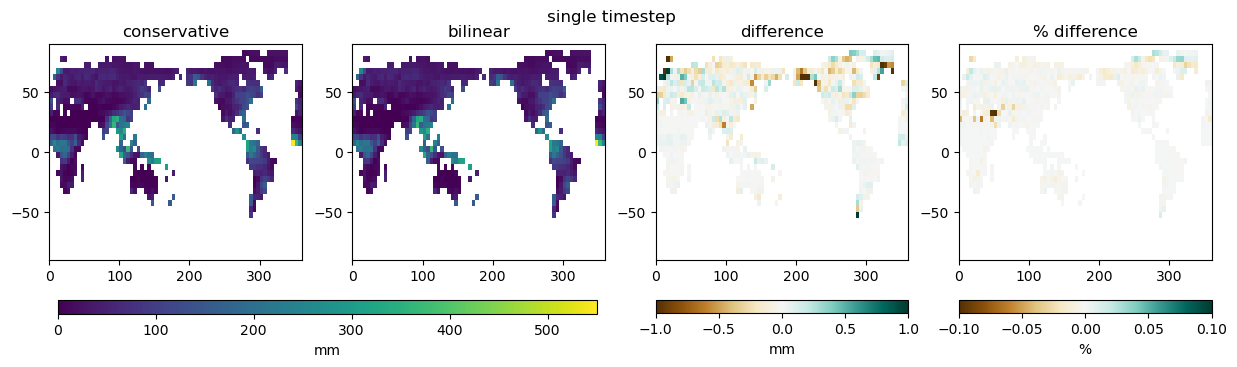

In [10]:
fig, axes = plt.subplots(1, 4, figsize = (15, 3.5))

i = 200
a = axes[0].pcolormesh(ds_regrid.lon, ds_regrid.lat, ds_regrid.isel(time = i).pr, vmin = 0, vmax = 550)
axes[1].pcolormesh(ds_regrid.lon, ds_regrid.lat, ds_regrid_bi.isel(time = i).pr, vmin = 0, vmax = 550)

plt.colorbar(a, ax = [axes[0], axes[1]], orientation = "horizontal", fraction = 0.05, 
                 aspect = 40, label = "mm")
b = axes[2].pcolormesh(ds_regrid.lon, ds_regrid.lat, (ds_regrid_bi - ds_regrid).isel(time = i).pr, cmap = "BrBG", vmin = -1, vmax = 1)
plt.colorbar(b, ax = axes[2], orientation = "horizontal", fraction = 0.05, label = "mm")

c = axes[3].pcolormesh(ds_regrid.lon, ds_regrid.lat, ((ds_regrid_bi - ds_regrid)/ds_regrid).isel(time = i).pr, cmap = "BrBG", vmin = -0.1, vmax = 0.1)
plt.colorbar(c, ax = axes[3], orientation = "horizontal", fraction = 0.05, label = "%")

axes[0].set(title = "conservative")
axes[1].set(title = "bilinear")
axes[2].set(title = "difference")
axes[3].set(title = "% difference")
plt.suptitle("single timestep")

Text(0.5, 0.98, 'mean')

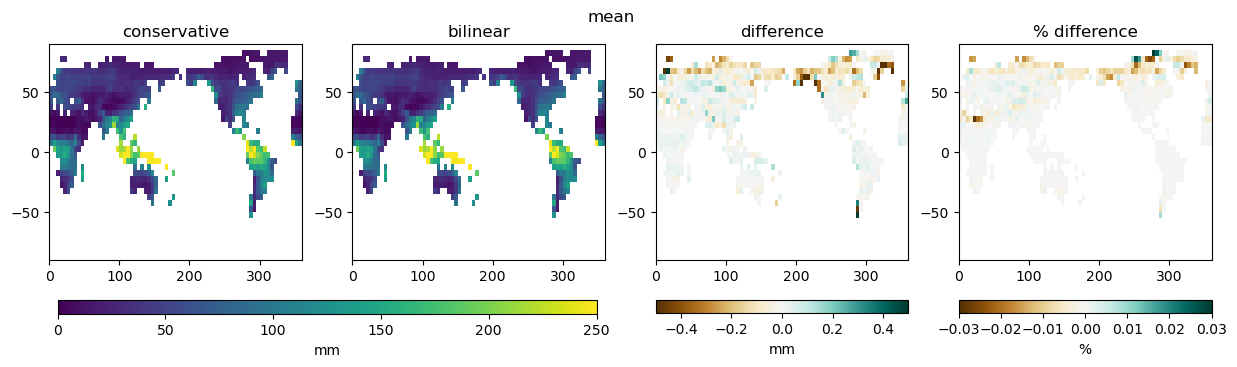

In [11]:
fig, axes = plt.subplots(1, 4, figsize = (15, 3.5))

a = axes[0].pcolormesh(ds_regrid.lon, ds_regrid.lat, ds_regrid.mean(dim = "time").pr, vmin = 0, vmax = 250)
axes[1].pcolormesh(ds_regrid.lon, ds_regrid.lat, ds_regrid_bi.mean(dim = "time").pr, vmin = 0, vmax = 250)

plt.colorbar(a, ax = [axes[0], axes[1]], orientation = "horizontal", fraction = 0.05, 
                 aspect = 40, label = "mm")
b = axes[2].pcolormesh(ds_regrid.lon, ds_regrid.lat, (ds_regrid_bi.mean(dim = "time") - ds_regrid.mean(dim = "time")).pr, 
                       cmap = "BrBG", vmin = -0.5, vmax = 0.5)
plt.colorbar(b, ax = axes[2], orientation = "horizontal", fraction = 0.05, label = "mm")

c = axes[3].pcolormesh(ds_regrid.lon, ds_regrid.lat, ((ds_regrid_bi.mean(dim = "time") - ds_regrid.mean(dim = "time"))/ds_regrid.mean(dim = "time")).pr, 
                       cmap = "BrBG", vmin = -0.03, vmax = 0.03)
plt.colorbar(c, ax = axes[3], orientation = "horizontal", fraction = 0.05, label = "%")

axes[0].set(title = "conservative")
axes[1].set(title = "bilinear")
axes[2].set(title = "difference")
axes[3].set(title = "% difference")
plt.suptitle("mean")

Text(0.5, 0.98, 'standard deviation')

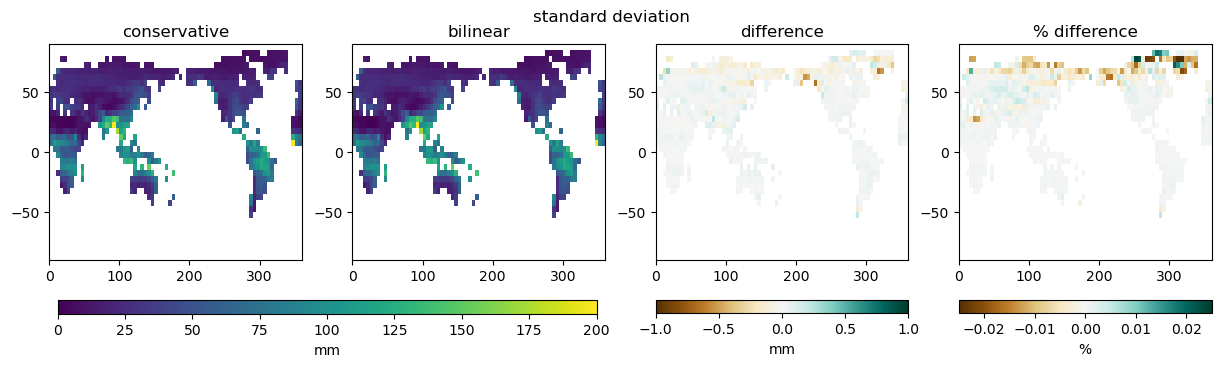

In [12]:
fig, axes = plt.subplots(1, 4, figsize = (15, 3.5))

a = axes[0].pcolormesh(ds_regrid.lon, ds_regrid.lat, ds_regrid.std(dim = "time").pr, vmin = 0, vmax = 200)
axes[1].pcolormesh(ds_regrid.lon, ds_regrid.lat, ds_regrid_bi.std(dim = "time").pr, vmin = 0, vmax = 200)

plt.colorbar(a, ax = [axes[0], axes[1]], orientation = "horizontal", fraction = 0.05, 
                 aspect = 40, label = "mm")
b = axes[2].pcolormesh(ds_regrid.lon, ds_regrid.lat, (ds_regrid_bi.std(dim = "time") - ds_regrid.std(dim = "time")).pr, cmap = "BrBG", vmin = -1, vmax = 1)
plt.colorbar(b, ax = axes[2], orientation = "horizontal", fraction = 0.05, label = "mm")

c = axes[3].pcolormesh(ds_regrid.lon, ds_regrid.lat, ((ds_regrid_bi.std(dim = "time") - ds_regrid.std(dim = "time"))/ds_regrid.std(dim = "time")).pr, 
                       cmap = "BrBG", vmin = -0.025, vmax = 0.025)
plt.colorbar(c, ax = axes[3], orientation = "horizontal", fraction = 0.05, label = "%")

axes[0].set(title = "conservative")
axes[1].set(title = "bilinear")
axes[2].set(title = "difference")
axes[3].set(title = "% difference")
plt.suptitle("standard deviation")

#### Compare shifted version of GPCC

In [13]:
ds_pt5 = xr.open_dataset("../../../../DATA/GPCC_Monthly_Precip/v2020/precip.mon.total.v2020.nc").rename({"precip":"pr"})

In [14]:
ds_pt5

<xarray.Dataset> Size: 2GB
Dimensions:  (lat: 360, lon: 720, time: 1548)
Coordinates:
  * lat      (lat) float32 1kB 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * lon      (lon) float32 3kB 0.25 0.75 1.25 1.75 ... 358.2 358.8 359.2 359.8
  * time     (time) datetime64[ns] 12kB 1891-01-01 1891-02-01 ... 2019-12-01
Data variables:
    pr       (time, lat, lon) float32 2GB ...
Attributes:
    Original_Source:  http://www.dwd.de/en/FundE/Klima/KLIS/int/GPCC/GPCC.htm...
    Reference:        Users of the data sets are kindly requested to give fee...
    original_source:  ftp://ftp-anon.dwd.de/pub/data/gpcc/html/fulldata_downl...
    Conventions:      CF 1.0
    dataset_title:    Global Precipitation Climatology Centre (GPCC)
    title:            GPCC Full Data Reanalysis Version 2018 0.5x0.5 Monthly ...
    history:          Created 09/2018  based on V2018 data obtained via ftp
    References:       https://www.psl.noaa.gov/data/gridded/data.gpcc.html

In [15]:
pt5_grid_with_bounds = xr.Dataset({'lon': ds_pt5.lon,
                           'lat': ds_pt5.lat,
                           'lon_b': np.linspace(0, 360, 721), 
                           'lat_b': np.linspace(90, -90, 361),
                          })

shifted_2pt5_grid = xr.Dataset({'lon': ds.lon-1,
                           'lat': ds.lat,
                           'lon_b': np.linspace(0-1, 360-1, 145), 
                           'lat_b': np.linspace(90, -90, 73),
                          })


In [16]:
# use bilinear to calculate gridding mask for conservative_normed regridding
shifted_2pt5_regridder_bi = xe.Regridder(pt5_grid_with_bounds, shifted_2pt5_grid, method='bilinear', periodic=True)
ds_shifted_bi = shifted_2pt5_regridder_bi(ds_pt5, keep_attrs=True)

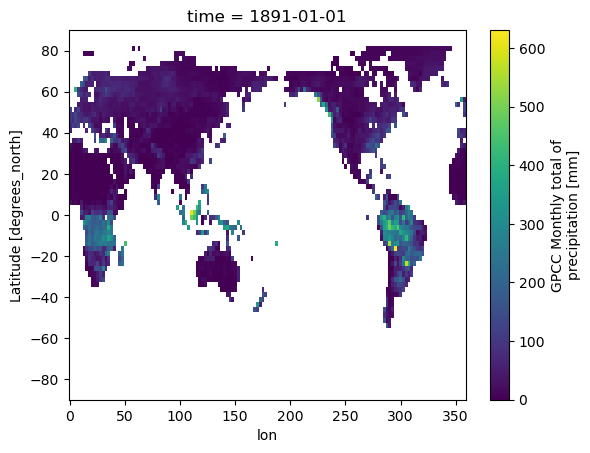

In [17]:
# check shifted 2.5 degree map
ds_shifted_bi.isel(time = 0).pr.plot();

Check grids: 

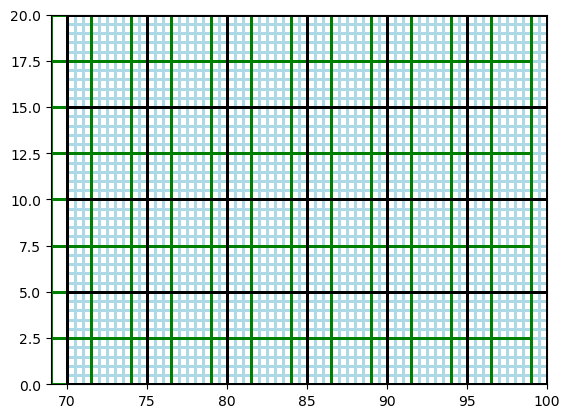

In [18]:
# create a plot of grids to double check
fig, ax = plt.subplots()

ax.pcolormesh(ds_pt5.sel(lon = slice(70, 100)).lon, ds_pt5.sel(lat = slice(20,0)).lat, 
                     ds_pt5.sel(lon = slice(70, 100), lat = slice(20,0)).isel(time = 0).pr, 
                     edgecolor = "lightblue", facecolor = "none")
ax.pcolormesh(ds_shifted_bi.sel(lon = slice(70, 100)).lon, ds_shifted_bi.sel(lat = slice(20,0)).lat, 
                     ds_shifted_bi.sel(lon = slice(70, 100), lat = slice(20,0)).isel(time = 0).pr, 
                     edgecolor = "green", facecolor = "none")
ax.pcolormesh(ds_regrid_bi.sel(lon = slice(70, 100)).lon, ds_regrid_bi.sel(lat = slice(0,20)).lat, 
                     ds_regrid_bi.sel(lon = slice(70, 100), lat = slice(0,20)).isel(time = 0).pr, 
                     edgecolor = "black", facecolor = "none");

In [19]:
pt5_grid_with_bounds["mask"] = xr.where(~np.isnan(ds_pt5["pr"].isel(time=0)), 1, 0).drop_vars("time")
shifted_2pt5_grid["mask"] = xr.where(~np.isnan(ds_shifted_bi["pr"].isel(time=0)), 1, 0).drop_vars("time")

In [20]:
shifted_2pt5_regridder = xe.Regridder(pt5_grid_with_bounds, shifted_2pt5_grid, method='conservative_normed', periodic=True)
ds_shifted = shifted_2pt5_regridder(ds_pt5, keep_attrs=True)

shifted_regridder = xe.Regridder(shifted_2pt5_grid, dest_grid_with_bounds, method='conservative_normed', periodic=True)
ds_shift_regrid = shifted_regridder(ds_shifted, keep_attrs=True)

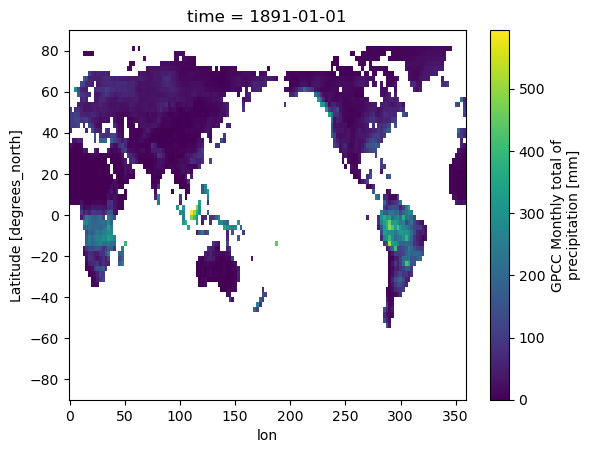

In [21]:
## check shifted 2.5 grid with conservative regridding
ds_shifted.isel(time = 0).pr.plot()

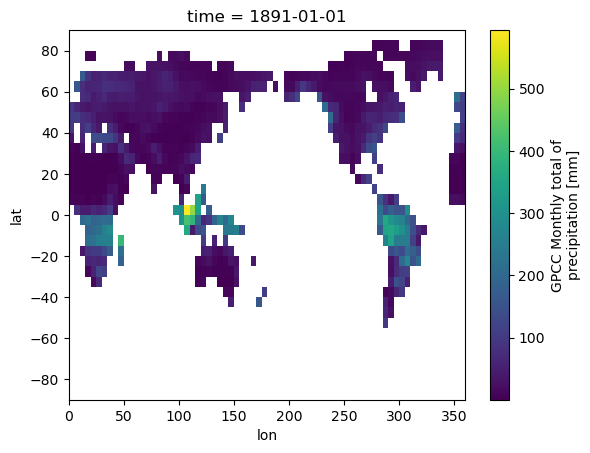

In [22]:
## check 5x5 grid from shifted 2.5 grid using conservative regridding
ds_shift_regrid.isel(time = 0).pr.plot()

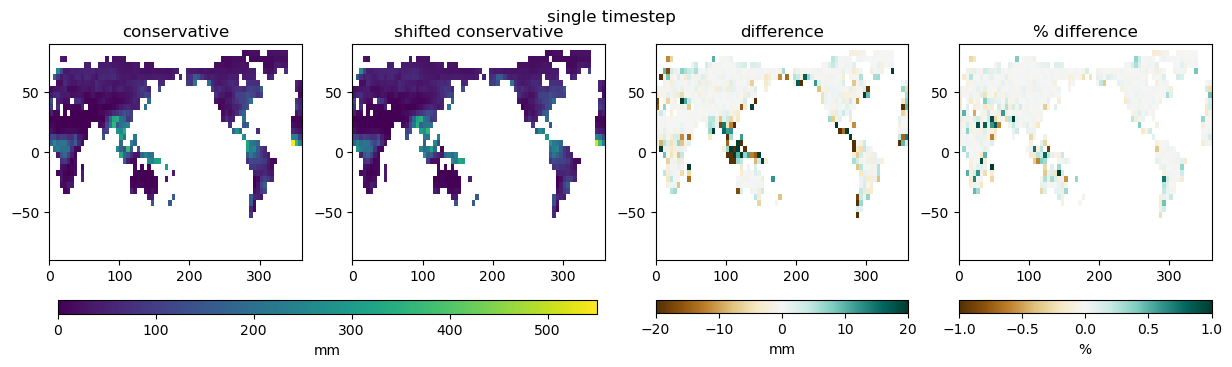

In [23]:
fig, axes = plt.subplots(1, 4, figsize = (15, 3.5))

i = 200
a = axes[0].pcolormesh(ds_regrid.lon, ds_regrid.lat, ds_regrid.isel(time = i).pr, vmin = 0, vmax = 550)
axes[1].pcolormesh(ds_regrid.lon, ds_regrid.lat, ds_shift_regrid.isel(time = i).pr, vmin = 0, vmax = 550)

plt.colorbar(a, ax = [axes[0], axes[1]], orientation = "horizontal", fraction = 0.05, 
                 aspect = 40, label = "mm")
b = axes[2].pcolormesh(ds_regrid.lon, ds_regrid.lat, (ds_shift_regrid - ds_regrid).isel(time = i).pr, cmap = "BrBG", vmin = -20, vmax = 20)
plt.colorbar(b, ax = axes[2], orientation = "horizontal", fraction = 0.05, label = "mm")

c = axes[3].pcolormesh(ds_regrid.lon, ds_regrid.lat, ((ds_shift_regrid - ds_regrid)/ds_regrid).isel(time = i).pr, cmap = "BrBG", vmin = -1, vmax = 1)
plt.colorbar(c, ax = axes[3], orientation = "horizontal", fraction = 0.05, label = "%")

axes[0].set(title = "conservative")
axes[1].set(title = "shifted conservative")
axes[2].set(title = "difference")
axes[3].set(title = "% difference")
plt.suptitle("single timestep");

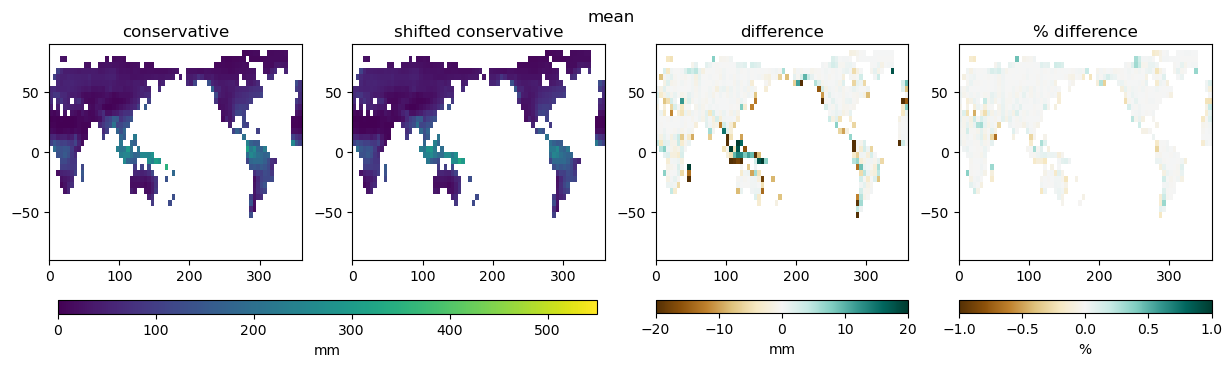

In [24]:
fig, axes = plt.subplots(1, 4, figsize = (15, 3.5))

a = axes[0].pcolormesh(ds_regrid.lon, ds_regrid.lat, ds_regrid.mean(dim = "time").pr, vmin = 0, vmax = 550)
axes[1].pcolormesh(ds_regrid.lon, ds_regrid.lat, ds_shift_regrid.mean(dim = "time").pr, vmin = 0, vmax = 550)

plt.colorbar(a, ax = [axes[0], axes[1]], orientation = "horizontal", fraction = 0.05, 
                 aspect = 40, label = "mm")
b = axes[2].pcolormesh(ds_regrid.lon, ds_regrid.lat, (ds_shift_regrid.mean(dim = "time") - ds_regrid.mean(dim = "time")).pr, 
                       cmap = "BrBG", vmin = -20, vmax = 20)
plt.colorbar(b, ax = axes[2], orientation = "horizontal", fraction = 0.05, label = "mm")

c = axes[3].pcolormesh(ds_regrid.lon, ds_regrid.lat, ((ds_shift_regrid.mean(dim = "time") - ds_regrid.mean(dim = "time"))/ds_regrid.mean(dim = "time")).pr, 
                       cmap = "BrBG", vmin = -1, vmax = 1)
plt.colorbar(c, ax = axes[3], orientation = "horizontal", fraction = 0.05, label = "%")

axes[0].set(title = "conservative")
axes[1].set(title = "shifted conservative")
axes[2].set(title = "difference")
axes[3].set(title = "% difference")
plt.suptitle("mean");

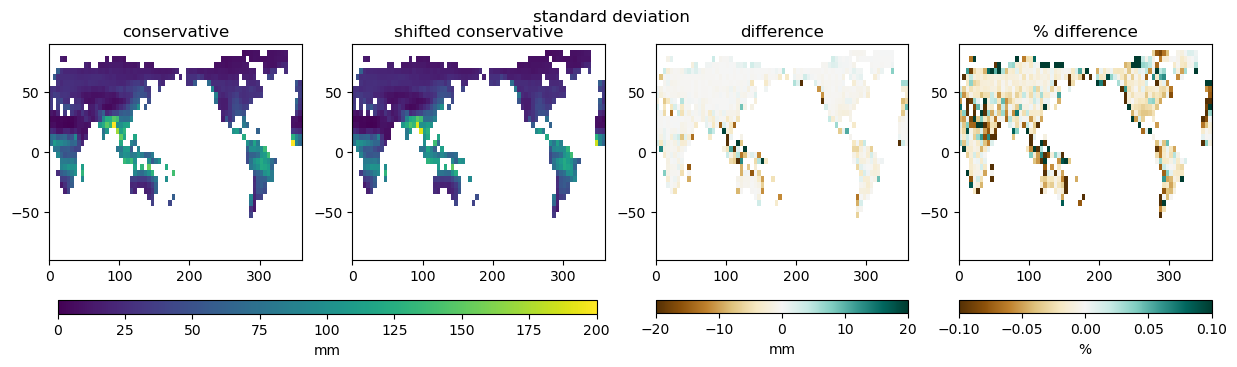

In [25]:
fig, axes = plt.subplots(1, 4, figsize = (15, 3.5))

a = axes[0].pcolormesh(ds_regrid.lon, ds_regrid.lat, ds_regrid.std(dim = "time").pr, vmin = 0, vmax = 200)
axes[1].pcolormesh(ds_regrid.lon, ds_regrid.lat, ds_shift_regrid.std(dim = "time").pr, vmin = 0, vmax = 200)

plt.colorbar(a, ax = [axes[0], axes[1]], orientation = "horizontal", fraction = 0.05, 
                 aspect = 40, label = "mm")
b = axes[2].pcolormesh(ds_regrid.lon, ds_regrid.lat, (ds_shift_regrid.std(dim = "time") - ds_regrid.std(dim = "time")).pr, 
                       cmap = "BrBG", vmin = -20, vmax = 20)
plt.colorbar(b, ax = axes[2], orientation = "horizontal", fraction = 0.05, label = "mm")

c = axes[3].pcolormesh(ds_regrid.lon, ds_regrid.lat, ((ds_shift_regrid.std(dim = "time") - ds_regrid.std(dim = "time"))/ds_regrid.std(dim = "time")).pr, 
                       cmap = "BrBG", vmin = -.1, vmax = .1)
plt.colorbar(c, ax = axes[3], orientation = "horizontal", fraction = 0.05, label = "%")

axes[0].set(title = "conservative")
axes[1].set(title = "shifted conservative")
axes[2].set(title = "difference")
axes[3].set(title = "% difference")
plt.suptitle("standard deviation");

#### Save regridded data

In [26]:
# original 2.5 degree grid but new file and variable name
ds.to_netcdf("../processed_data/gpcc/gpcc_mon_precip_2pt5x2pt5.nc")

In [27]:
# land mask for 2.5 degree grid from original data
landmask_25 = xr.where(ds.isel(time = 0).pr.isnull(), 0, 1).rename("mask")
landmask_25.to_netcdf("../processed_data/gpcc_land_mask_2pt5x2pt5.nc")

In [28]:
# landmask for 5 degree grid
landmask_5 = xr.where(ds_regrid_bi.isel(time = 0).pr.isnull(), 0, 1).rename("mask")
#landmask_5.to_netcdf("../processed_data/gpcc_land_mask_5x5.nc")

In [29]:
# 5x5 degree grid using conservative regridding
ds_regrid.to_netcdf("../processed_data/gpcc/gpcc_mon_precip_5x5.nc")

In [30]:
# 5x5 degree grid using conservative regridding from shifted 2.5 degree grid
ds_shift_regrid.to_netcdf("../processed_data/gpcc/gpcc_mon_precip_5x5_shifted.nc")

### GPCP Monthly precip

In [31]:
gpcp = xr.open_mfdataset("/davenport-scratch/DATA/GPCP/precip.mon.mean.nc").rename({"precip": "pr"})
gpcp = gpcp.reindex(lat=list(reversed(gpcp.lat)))

In [32]:
gpcp

<xarray.Dataset> Size: 23MB
Dimensions:    (lat: 72, lon: 144, time: 552, nv: 2)
Coordinates:
  * lat        (lat) float32 288B 88.75 86.25 83.75 ... -83.75 -86.25 -88.75
  * lon        (lon) float32 576B 1.25 3.75 6.25 8.75 ... 353.8 356.2 358.8
  * time       (time) datetime64[ns] 4kB 1979-01-01 1979-02-01 ... 2024-12-01
Dimensions without coordinates: nv
Data variables:
    time_bnds  (time, nv) datetime64[ns] 9kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    lat_bnds   (lat, nv) float32 576B dask.array<chunksize=(72, 2), meta=np.ndarray>
    lon_bnds   (lon, nv) float32 1kB dask.array<chunksize=(144, 2), meta=np.ndarray>
    pr         (time, lat, lon) float32 23MB dask.array<chunksize=(1, 72, 144), meta=np.ndarray>
Attributes: (12/18)
    Conventions:           CF-1.0
    curator:               Dr. Jian-Jian Wang\nESSIC, University of Maryland ...
    citation:              Adler, R.F., G.J. Huffman, A. Chang, R. Ferraro, P...
    title:                 GPCP Version 2.3 Combined Precipitation Dataset (F...
    platform:              NOAA POES (Polar Orbiting Environmental Satellites)
    source_obs:            CDR RSS SSMI/SSMIS Tbs over ocean \nCDR SSMI/SSMIS...
    ...                    ...
    source:                https://www.ncei.noaa.gov/data/global-precipitatio...
    source_documentation:  https://www.ncdc.noaa.gov/cdr/atmospheric/precipit...
    NCO:                   4.6.9
    history:               Generated at NOAA/ESRL PSD Sep 9 2016 based on dat...
    References:            http://www.psl.noaa.gov/data/gridded/data.gpcp.html
    data_comment:          Interim data covers 2024/11 through latest.

In [33]:
landmask_25 = xr.open_dataset("../processed_data/gpcc_land_mask_2pt5x2pt5.nc").rename({"mask": "pr"})

In [34]:
## mask gpcp using gpcc bounds so that 5x5 regridding is based on land grids only
gpcp = xr.where(landmask_25.pr == 0, np.nan, gpcp.pr).to_dataset()

In [35]:
gpcp_grid_with_bounds = xr.Dataset({'lon': gpcp.lon,
                           'lat': gpcp.lat,
                           'lon_b': np.linspace(0, 360, 145), 
                           'lat_b': np.linspace(90, -90, 73),
                          })

In [36]:
gpcp_grid_with_bounds["mask"] = xr.where(~np.isnan(gpcp.pr.isel(time=0)), 1, 0).drop_vars("time")

In [37]:
gpcp_regridder = xe.Regridder(gpcp_grid_with_bounds, dest_grid_with_bounds, method='conservative_normed', periodic=True)
gpcp_regrid = gpcp_regridder(gpcp, keep_attrs=True)

In [38]:
gpcp_regrid = xr.where(landmask_5 == 0, np.nan, gpcp_regrid)

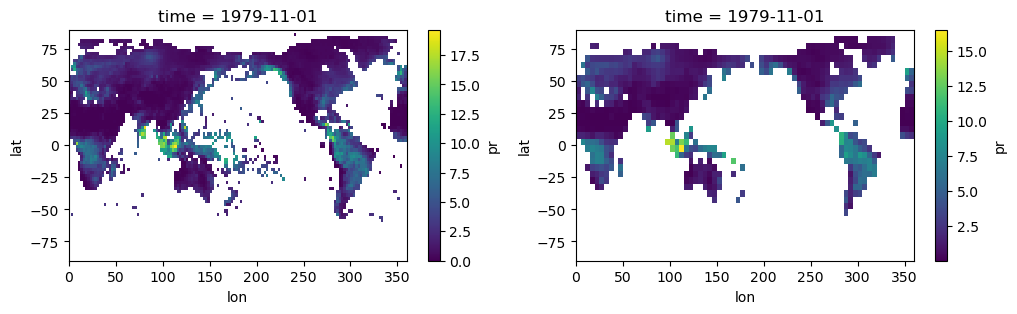

In [39]:
fig, axes = plt.subplots(1, 2, figsize = (12, 3))

gpcp.isel(time = 10).pr.plot(ax = axes[0])
gpcp_regrid.isel(time = 10).pr.plot(ax = axes[1])

In [40]:
gpcp_regrid.to_netcdf("../processed_data/gpcp/gpcp_mon_precip_5x5.nc")

### CPC daily precip

In [41]:
cpc_files = sorted(glob.glob("/davenport-scratch/DATA/CPC_Unified_GaugeBased_Daily_Precip/precip.*.nc"))

In [42]:
cpc = xr.open_mfdataset(cpc_files).rename({"precip":"pr"})

In [43]:
cpc

<xarray.Dataset> Size: 17GB
Dimensions:  (time: 16802, lat: 360, lon: 720)
Coordinates:
  * lat      (lat) float32 1kB 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * lon      (lon) float32 3kB 0.25 0.75 1.25 1.75 ... 358.2 358.8 359.2 359.8
  * time     (time) datetime64[ns] 134kB 1979-01-01 1979-01-02 ... 2024-12-31
Data variables:
    pr       (time, lat, lon) float32 17GB dask.array<chunksize=(1, 360, 720), meta=np.ndarray>
Attributes:
    Conventions:    CF-1.0
    version:        V1.0
    history:        created 9/2016 by CAS NOAA/ESRL PSD
    title:          CPC GLOBAL PRCP V1.0
    dataset_title:  CPC GLOBAL PRCP V1.0
    Source:         ftp://ftp.cpc.ncep.noaa.gov/precip/CPC_UNI_PRCP/
    References:     https://www.psl.noaa.gov/data/gridded/data.cpc.globalprec...

In [44]:
cpc_grid_with_bounds = xr.Dataset({'lon': cpc.lon,
                           'lat': cpc.lat,
                           'lon_b': np.linspace(0, 360, 721), 
                           'lat_b': np.linspace(90, -90, 361),
                          })

cpc_grid_with_bounds["mask"] = xr.where(~np.isnan(cpc["pr"].isel(time=0)), 1, 0).drop_vars("time")

In [45]:
cpc_regridder = xe.Regridder(cpc_grid_with_bounds, dest_grid_with_bounds, method='conservative_normed', periodic=True)
cpc_regrid = cpc_regridder(cpc, keep_attrs=True)

In [46]:
cpc_regrid = xr.where(landmask_5 == 0, np.nan, cpc_regrid)

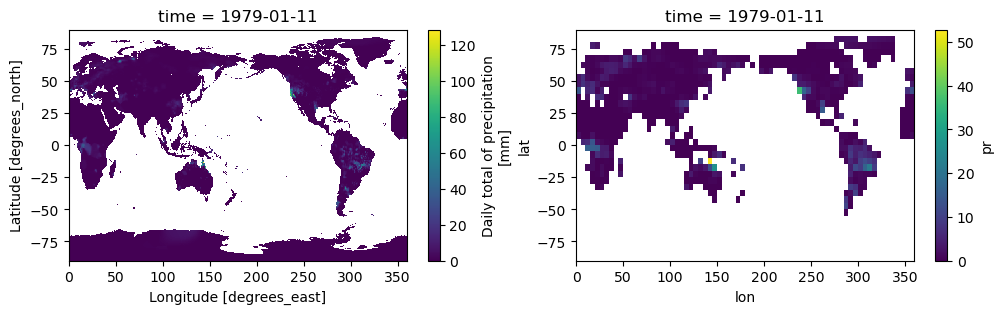

In [47]:
fig, axes = plt.subplots(1, 2, figsize = (12, 3))

cpc.isel(time = 10).pr.plot(ax = axes[0])
cpc_regrid.isel(time = 10).pr.plot(ax = axes[1])

In [48]:
cpc_regrid.to_netcdf("../processed_data/cpc/cpc_day_precip_5x5.nc")

### Test shifted CPC data

In [49]:
shifted_2pt5_regridder = xe.Regridder(cpc_grid_with_bounds, shifted_2pt5_grid, method='conservative_normed', periodic=True)
cpc_shifted = shifted_2pt5_regridder(cpc, keep_attrs=True)

shifted_regridder = xe.Regridder(shifted_2pt5_grid, dest_grid_with_bounds, method='conservative_normed', periodic=True)
cpc_shift_regrid = shifted_regridder(cpc_shifted, keep_attrs=True)

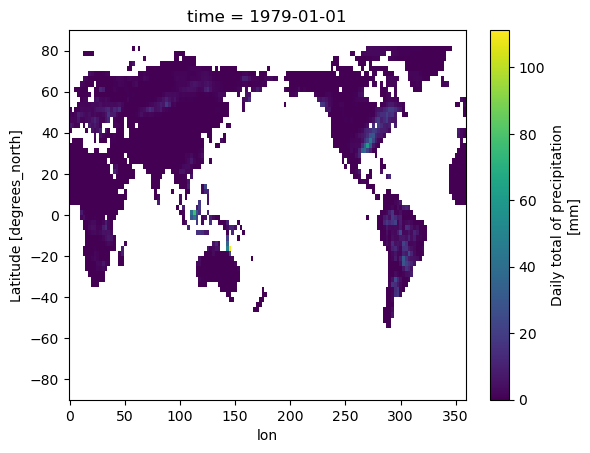

In [50]:
## check shifted 2.5 grid with conservative regridding
cpc_shifted.isel(time = 0).pr.plot()

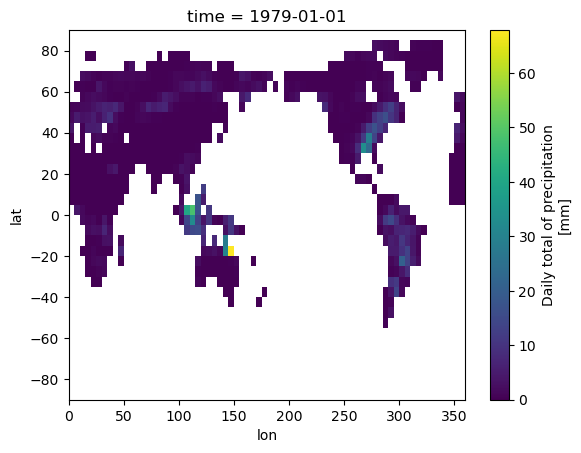

In [51]:
## check 5x5 grid from shifted 2.5 grid using conservative regridding
cpc_shift_regrid.isel(time = 0).pr.plot()

In [54]:
cpc_shift_regrid.to_netcdf("../processed_data/cpc/cpc_day_precip_5x5_shifted.nc")